# Taller de NLP: Procesamiento de Lenguaje y Análisis de Sentimiento

**Autor:** Alejandro Alvarenga

**Objetivo:** aplicar un flujo completo de procesamiento de lenguaje natural sobre `feedback_clientes.csv`
(reseñas de clientes en español) para:

1. Limpiar y normalizar el texto, con lematización mediante spaCy.
2. Clasificar el sentimiento (Positivo, Neutral, Negativo) y visualizar la salud del feedback.
3. Medir similitud semántica frente a un "comentario ideal" usando embeddings.
4. Identificar con LDA los principales temas de queja entre los comentarios negativos.

**Sobre los datos:** el archivo contiene reseñas de productos de tipos muy distintos (electrónica, hogar, accesorios,
alimentación). Cada registro trae `text` (comentario) y `label` (calificación de 0 a 4, equivalente a 1-5 estrellas).
Esa calificación se usa como referencia para evaluar la clasificación de sentimiento.

## 0. Configuración del entorno

Se usan `spaCy` (modelo `es_core_news_md`, con vectores), `TextBlob`, `Gensim` (LDA), `scikit-learn`, `Pandas` y `Matplotlib`.

In [1]:
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from textblob import TextBlob
from gensim import corpora, models
from gensim.models import CoherenceModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 110)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

# Modelo mediano en español (incluye vectores de palabras). Para mayor precisión puede cambiarse por "es_core_news_lg".
nlp = spacy.load("es_core_news_md", disable=["parser", "ner"])
print("spaCy", spacy.__version__, "| modelo:", nlp.meta["name"], nlp.meta["version"])

/Users/alejandroalvarenga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


spaCy 3.8.11 | modelo: core_news_md 3.8.0


## Fase 1: Ingesta y Sentimiento

### Paso 1: Limpieza técnica

Se carga el archivo y se revisa su estructura. Antes de procesar se eliminan los comentarios duplicados, que
distorsionarían las frecuencias.

In [2]:
df = pd.read_csv("feedback_clientes.csv", encoding="utf-8-sig")
print("Registros originales:", len(df))
print("Nulos por columna:\n", df.isna().sum(), sep="")
print("Comentarios duplicados:", df["text"].duplicated().sum())

df = df.drop_duplicates(subset="text").reset_index(drop=True)
print("Registros tras eliminar duplicados:", len(df))
print("\nDistribución de la calificación original (label):")
print(df["label"].value_counts().sort_index())
df.head()

Registros originales: 10000
Nulos por columna:
id            0
text          0
label         0
label_text    0
dtype: int64
Comentarios duplicados: 20
Registros tras eliminar duplicados: 9980

Distribución de la calificación original (label):
label
0    2000
1    1999
2    1999
3    1993
4    1989
Name: count, dtype: int64


,id,text,label,label_text
0,es_0446108,Pedí la botella por comodidad al salir a pasear con Sherlock... Pero ha sido una decepción. Cuando llegó t...,0,0
1,es_0328818,"lo compré por ser SONY, pero la calidad de sonido me parece pésima. Ni siquiera se oyen los graves ... sol...",0,0
2,es_0839092,"Decepcionada. El mod venía con claros signos de uso, y la pantalla se ve un fallo en el display. Las bater...",0,0
3,es_0757233,"Autentica desilusión, no tiene nada que ver con la foto.",0,0
4,es_0727971,No me hicieron la devolución del producto.,0,0


La normalización incluye: minúsculas, eliminación de URLs, números y puntuación, remoción de *stopwords* y lematización
con spaCy.

**Decisión de diseño:** la lista de stopwords de spaCy incluye palabras como *no*, *sin*, *nunca* o *muy*. En análisis de
sentimiento estas palabras cambian el significado ("no funciona" frente a "funciona"), por lo que se excluyen de la lista
de palabras a eliminar.

In [3]:
# Palabras que spaCy marca como stopword pero que aportan información de polaridad o intensidad
CONSERVAR = ["no", "nunca", "ni", "sin", "poco", "nada", "tampoco", "muy", "más", "bien", "mal", "mucho", "menos", "bastante"]
for palabra in CONSERVAR:
    nlp.vocab[palabra].is_stop = False


def limpiar_texto(texto: str) -> str:
    """Pasa a minúsculas y elimina URLs, números, signos de puntuación y espacios repetidos."""
    texto = texto.lower()
    texto = re.sub(r"http\S+", " ", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()


def lematizar(textos, lote=256):
    """
    Lematiza una serie de textos ya limpios con spaCy.
    Conserva solo los lemas de tokens que no son stopwords ni espacios.
    Usa nlp.pipe para procesar por lotes, que es mucho más rápido que llamar a nlp() fila por fila.
    """
    resultado = []
    for doc in nlp.pipe(textos, batch_size=lote):
        lemas = [t.lemma_ for t in doc if not t.is_stop and not t.is_space and len(t.lemma_) > 1]
        resultado.append(" ".join(lemas))
    return resultado


df["texto_limpio"] = df["text"].apply(limpiar_texto)
df["texto_lematizado"] = lematizar(df["texto_limpio"])
df[["text", "texto_lematizado"]].sample(6, random_state=1)

,text,texto_lematizado
2764,Me a gustado que lo montas enseguida! Lo que menos me a gustado:como el fieltro apenas tiene pelo las piez...,gustado montar menos gustado fieltro pelo pieza caer
4109,"Tallaje pequeño. Hay que comprar dos tallas más, si no te gusta que te apriete. Tejido muy suave al tacto....",tallaje pequeño comprar talla más no gustar aprietir tejido mucho suave tacto lavar él mano estropear lava...
6843,"El libro es muy chulo, bastante gordito, y con muchas pegatinas, y dibujos para colorear... muy completo. ...",libro mucho chulo bastante gordito pegatina dibujo colorear mucho completo recomeir compra
8625,Lo mejor que é comprado por Amazon.,comprado amazon
7105,Lee tarjeta de memoria y DNI electrónico.,leer tarjeta memoria dni electrónico
964,No lo he recibido aún (un mes después de hacer el pedido) y no encuentro la manera de contactar con el pro...,no recibir mes pedido no encontrar contactar proveedor solucionar asunto agradecer poder ayudar


### Paso 2: Clasificación de sentimiento

**Referencia.** La calificación `label` se agrupa en tres clases: 0 y 1 (1-2 estrellas) como *Negativo*, 2 (3 estrellas) como
*Neutral* y 3 y 4 (4-5 estrellas) como *Positivo*. Esta agrupación sirve como valor de referencia para medir qué tan bien
clasifica el texto por sí solo.

**TextBlob.** Se prueba primero TextBlob, que está entrenado con texto en inglés. Se espera que funcione mal con español.

In [4]:
MAPA_SENTIMIENTO = {0: "Negativo", 1: "Negativo", 2: "Neutral", 3: "Positivo", 4: "Positivo"}
df["sentimiento_ref"] = df["label"].map(MAPA_SENTIMIENTO)

df["polaridad_textblob"] = df["text"].apply(lambda t: TextBlob(t).sentiment.polarity)
corr = df["polaridad_textblob"].corr(df["label"])
print("Polaridad media (valor absoluto) de TextBlob:", round(df["polaridad_textblob"].abs().mean(), 3))
print("Correlación entre polaridad de TextBlob y la calificación:", round(corr, 3))

Polaridad media (valor absoluto) de TextBlob: 0.034
Correlación entre polaridad de TextBlob y la calificación: 0.092


**Resultado:** la polaridad media de TextBlob es de apenas 0.03 en valor absoluto y su correlación con la calificación del cliente es de 0.09, es decir, prácticamente no distingue entre reseñas buenas y malas. Esto confirma que su lexicón en inglés no sirve para español y justifica el uso de un clasificador entrenado con texto en español.

**Clasificador utilizado.** Como TextBlob no sirve para español, se entrena un modelo supervisado sencillo:
vectorización TF-IDF (unigramas y bigramas) sobre los textos lematizados y regresión logística. Para evitar evaluar con los
mismos datos con que se entrena, las predicciones se obtienen con validación cruzada de 5 particiones: cada comentario es
clasificado por un modelo que no lo vio durante el entrenamiento.

In [5]:
vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True)
X = vectorizador.fit_transform(df["texto_lematizado"])

modelo = LogisticRegression(max_iter=1000, C=2, class_weight="balanced")
df["sentimiento"] = cross_val_predict(modelo, X, df["sentimiento_ref"], cv=5)

print("Exactitud global:", round(accuracy_score(df["sentimiento_ref"], df["sentimiento"]), 3))
print(classification_report(df["sentimiento_ref"], df["sentimiento"]))

Exactitud global: 0.656
              precision    recall  f1-score   support

    Negativo       0.73      0.72      0.72      3999
     Neutral       0.34      0.39      0.36      1999
    Positivo       0.77      0.73      0.75      3982

    accuracy                           0.66      9980
   macro avg       0.61      0.61      0.61      9980
weighted avg       0.67      0.66      0.66      9980



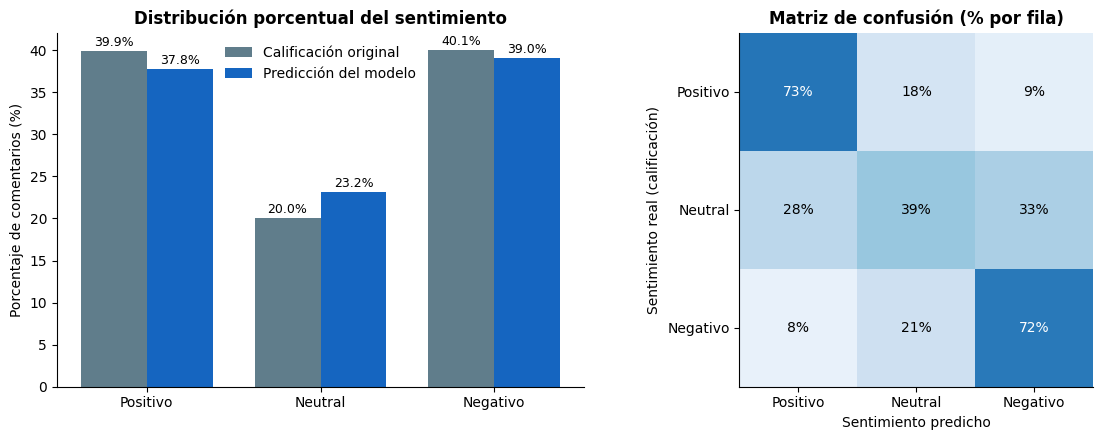

In [6]:
orden = ["Positivo", "Neutral", "Negativo"]
colores = {"Positivo": "#2e7d32", "Neutral": "#9e9e9e", "Negativo": "#c62828"}

pct_ref = df["sentimiento_ref"].value_counts(normalize=True).reindex(orden) * 100
pct_pred = df["sentimiento"].value_counts(normalize=True).reindex(orden) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x = np.arange(len(orden)); ancho = 0.38
axes[0].bar(x - ancho / 2, pct_ref.values, ancho, label="Calificación original", color="#607d8b")
axes[0].bar(x + ancho / 2, pct_pred.values, ancho, label="Predicción del modelo", color="#1565c0")
for i, (a, b) in enumerate(zip(pct_ref.values, pct_pred.values)):
    axes[0].text(i - ancho / 2, a + 0.6, f"{a:.1f}%", ha="center", fontsize=9)
    axes[0].text(i + ancho / 2, b + 0.6, f"{b:.1f}%", ha="center", fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(orden)
axes[0].set_ylabel("Porcentaje de comentarios (%)")
axes[0].set_title("Distribución porcentual del sentimiento", fontweight="bold")
axes[0].legend(frameon=False)

cm = confusion_matrix(df["sentimiento_ref"], df["sentimiento"], labels=orden, normalize="true") * 100
im = axes[1].imshow(cm, cmap="Blues", vmin=0, vmax=100)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(orden)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(orden)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{cm[i, j]:.0f}%", ha="center", va="center",
                     color="white" if cm[i, j] > 50 else "black")
axes[1].set_xlabel("Sentimiento predicho"); axes[1].set_ylabel("Sentimiento real (calificación)")
axes[1].set_title("Matriz de confusión (% por fila)", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretación analítica y de negocio:**

- La muestra está equilibrada por construcción: 40% de comentarios negativos, 20% neutrales y 40% positivos según la calificación. Esto significa que, en este conjunto, **cuatro de cada diez clientes tuvieron una mala experiencia**, una proporción alta para una empresa cuyo crecimiento depende de la recompra y de la reputación en el marketplace.
- El modelo alcanza una exactitud global de 65.6%. Detecta bien los extremos (F1 de 0.72 en negativos y 0.75 en positivos), pero el sentimiento **Neutral** es difícil de identificar (F1 de 0.36): las reseñas de 3 estrellas mezclan elogios y críticas en un mismo texto, y el modelo las reparte entre positivas y negativas. Es una limitación conocida del análisis de sentimiento en tres clases.
- Para el negocio, lo importante es que la clase **Negativo** se recupera con buena fiabilidad (73% de precisión): el modelo sirve para priorizar automáticamente qué comentarios revisar primero, aunque no debe usarse para decidir sobre reseñas neutrales.
- Los 3,897 comentarios que el modelo marca como negativos (39.0% del total) son la base del análisis de tópicos que sigue.

## Fase 2: Similitud y Modelado de Tópicos

### Embeddings (vectores)

Se define un "comentario ideal" que resume la experiencia que la empresa quiere generar. Cada comentario del dataset se
convierte en un vector (promedio de los vectores de sus palabras en el modelo `md` de spaCy) y se mide su similitud del
coseno con el comentario ideal. Se listan los 5 registros más cercanos.

In [7]:
COMENTARIO_IDEAL = ("El producto llegó a tiempo, funciona perfectamente y la calidad es excelente "
                    "para lo que cuesta. Muy recomendable.")

# Para los vectores solo se necesita el tokenizador y los vectores estáticos del modelo
nlp_vec = spacy.load("es_core_news_md", disable=["tagger", "morphologizer", "parser", "ner", "lemmatizer", "attribute_ruler"])

vectores = np.array([d.vector for d in nlp_vec.pipe(df["texto_limpio"], batch_size=256)])
vector_ideal = nlp_vec(limpiar_texto(COMENTARIO_IDEAL)).vector


def similitud_coseno(matriz, vector):
    """Similitud del coseno entre cada fila de `matriz` y un `vector`."""
    normas = np.linalg.norm(matriz, axis=1) * np.linalg.norm(vector)
    return matriz @ vector / np.where(normas == 0, 1, normas)


df["similitud_ideal"] = similitud_coseno(vectores, vector_ideal)

top5 = df.sort_values("similitud_ideal", ascending=False).head(5)
for _, fila in top5.iterrows():
    print(f"Similitud {fila.similitud_ideal:.3f} | {fila.sentimiento_ref} ({fila.label + 1} estrellas)")
    print("   ", fila.text[:230].replace("\n", " "), "\n")

Similitud 0.943 | Positivo (5 estrellas)
    La verdad es que no solo llegó a tiempo, sino que protege muy bien mis altavoces y es la medida correcta.. trae el compartimiento necesario para almacenar el cable del cargador.. y por lo demás, el material es bastante resistente 

Similitud 0.936 | Positivo (4 estrellas)
    Muy bien. Se adhiere correctamente y la medida es ideal. Un buen producto relacion calidad/precio. Totalmente recomendable. Volveria a comprarlo 

Similitud 0.927 | Positivo (4 estrellas)
    Pros: Buena calidad de sonido, apenas se aprecia la diferencia con cable que con este receptor y la distancia es bastante buena. Contras: A simple vista no parece que sea de muy buenos materiales para el precio que tiene pero su f 

Similitud 0.926 | Negativo (2 estrellas)
    La compramos para usarla como cabeza para un disfraz, pierde mucho pelo al peinarla, cuando quise hacerle tirabuzones con la plancha fue imposible , así que usé las tenacillas para hacerlos y bueno , algo mej

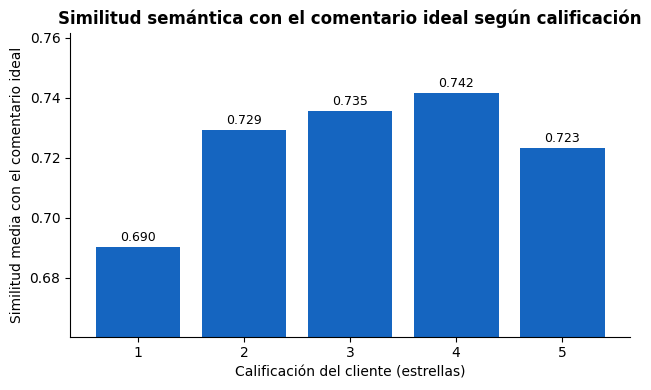

In [8]:
sim_por_estrella = df.groupby(df["label"] + 1)["similitud_ideal"].mean()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(sim_por_estrella.index.astype(str), sim_por_estrella.values, color="#1565c0")
ax.set_ylim(sim_por_estrella.min() - 0.03, sim_por_estrella.max() + 0.02)
for i, v in enumerate(sim_por_estrella.values):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xlabel("Calificación del cliente (estrellas)")
ax.set_ylabel("Similitud media con el comentario ideal")
ax.set_title("Similitud semántica con el comentario ideal según calificación", fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretación:** los cinco comentarios más cercanos al comentario ideal son, en su mayoría, reseñas de 4 y 5 estrellas que combinan los mismos elementos del texto de referencia: llegada a tiempo, buena calidad, buen precio y recomendación. Esto indica que los vectores capturan bien el *contexto* de una compra satisfactoria.

También se observa una limitación importante: el cuarto resultado es una reseña de 2 estrellas. Los embeddings promediados miden cercanía **temática** (hablar de calidad, precio y compra) y no la polaridad; una queja escrita con vocabulario parecido al de un elogio puede quedar cerca. Por eso la similitud sirve para explorar y encontrar ejemplos, pero no reemplaza al clasificador de sentimiento.

En el gráfico, las reseñas de 1 estrella son las más alejadas del comentario ideal (0.690), mientras que las de 2 a 5 estrellas se ubican entre 0.723 y 0.742. La diferencia es pequeña, pero consistente con que los clientes más insatisfechos usan un vocabulario distinto (devoluciones, roturas, retrasos).

### Paso 4: LDA sobre negativos

Se aplica LDA (Gensim) solo sobre los comentarios clasificados como **Negativo** por el modelo, con `num_topics=3`.
Antes se eliminan palabras muy genéricas del dominio (*producto*, *comprar*, *pedir*, etc.) que aparecen en casi todas las
quejas y no ayudan a distinguir temas, y se filtran términos demasiado raros o demasiado frecuentes.

In [9]:
negativos = df[df["sentimiento"] == "Negativo"].copy()
print("Comentarios negativos analizados:", len(negativos))

STOPWORDS_DOMINIO = {
    "producto", "comprar", "compra", "pedir", "tener", "haber", "hacer", "ser", "estar", "poder", "ir", "dar", "ver",
    "llegar", "funcionar", "vez", "día", "más", "muy", "no", "nunca", "ni", "sin", "poco", "nada", "tampoco", "bien",
    "mal", "mucho", "menos", "bastante", "solo", "tan", "cosa", "así", "aunque", "artículo", "amazon", "decir", "querer",
}

textos_lda = [[w for w in t.split() if w not in STOPWORDS_DOMINIO and len(w) > 2] for t in negativos["texto_lematizado"]]

diccionario = corpora.Dictionary(textos_lda)
diccionario.filter_extremes(no_below=15, no_above=0.3)
corpus = [diccionario.doc2bow(t) for t in textos_lda]

lda = models.LdaModel(corpus=corpus, id2word=diccionario, num_topics=3, random_state=42,
                      passes=10, iterations=100, alpha="auto", eta="auto")

coherencia = CoherenceModel(model=lda, texts=textos_lda, dictionary=diccionario, coherence="c_v").get_coherence()
print("Coherencia c_v:", round(coherencia, 3), "\n")
for i in range(3):
    palabras = ", ".join(p for p, _ in lda.show_topic(i, topn=12))
    print(f"Tópico {i}: {palabras}")

Comentarios negativos analizados: 3897


/Users/alejandroalvarenga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alejandroalvarenga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alejandroalvarenga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alejandroalvarenga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL

Coherencia c_v: 0.387 

Tópico 0: mes, durar, luz, poner, romper, año, batería, barato, tiempo, encender, usar, talla
Tópico 1: devolver, esperar, recibir, venir, vendedor, dejar, pedido, dinero, cargar, paquete, devolución, poner
Tópico 2: calidad, malo, quedar, venir, gustar, pantalla, pequeño, color, romper, protector, recomendar, cristal


El modelo identificó tres grupos de palabras con significado propio. La coherencia c_v es de 0.39, un valor moderado, esperable en un corpus corto (comentarios de pocas líneas) y de productos muy variados; aun así los tres tópicos se pueden interpretar con claridad a partir de sus palabras clave y de los comentarios más representativos que se muestran más abajo.

topico_nombre
Calidad y ajuste de accesorios       44.6
Envío, devoluciones y vendedor       34.6
Durabilidad y fallos del producto    20.7
Name: count, dtype: float64


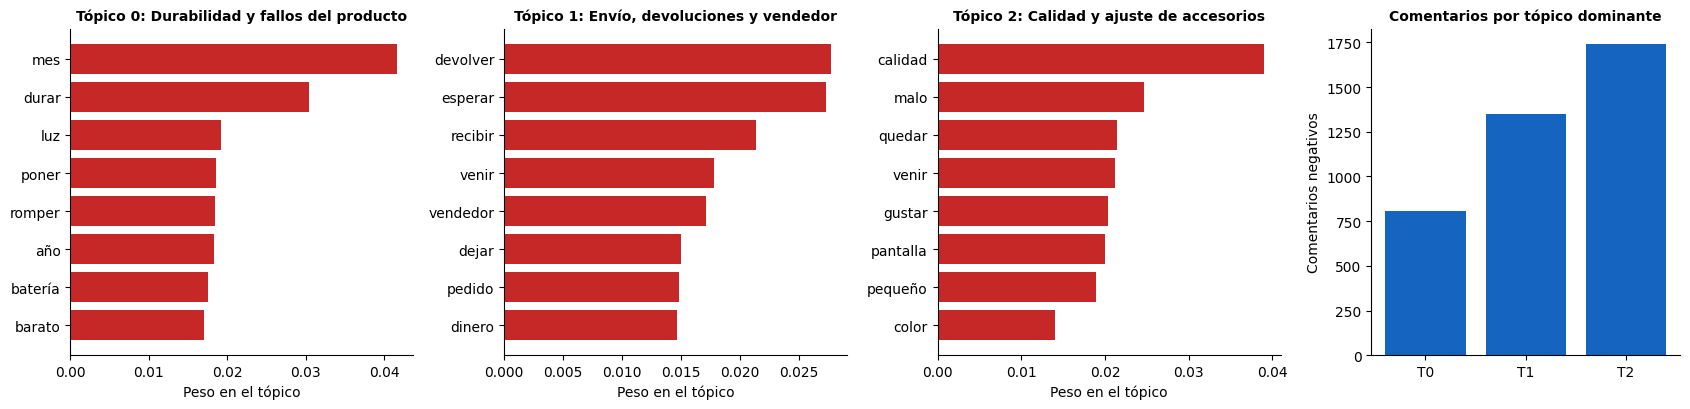

In [10]:
NOMBRES_TOPICOS = {0: 'Durabilidad y fallos del producto', 1: 'Envío, devoluciones y vendedor', 2: 'Calidad y ajuste de accesorios'}

negativos["topico"] = [max(lda.get_document_topics(bow), key=lambda x: x[1])[0] for bow in corpus]
negativos["topico_nombre"] = negativos["topico"].map(NOMBRES_TOPICOS)
conteo = negativos["topico_nombre"].value_counts()
print((conteo / conteo.sum() * 100).round(1))

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), gridspec_kw={"width_ratios": [1, 1, 1, 0.9]})
for i in range(3):
    top = lda.show_topic(i, topn=8)[::-1]
    axes[i].barh([p for p, _ in top], [w for _, w in top], color="#c62828")
    axes[i].set_title(f"Tópico {i}: {NOMBRES_TOPICOS[i]}", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Peso en el tópico")
axes[3].bar(range(3), [conteo.get(NOMBRES_TOPICOS[i], 0) for i in range(3)], color="#1565c0")
axes[3].set_xticks(range(3)); axes[3].set_xticklabels([f"T{i}" for i in range(3)])
axes[3].set_ylabel("Comentarios negativos")
axes[3].set_title("Comentarios por tópico dominante", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

In [11]:
# Ejemplos representativos de cada tópico (comentarios donde el tópico tiene mayor probabilidad)
for i in range(3):
    prob = [dict(lda.get_document_topics(bow, minimum_probability=0)).get(i, 0) for bow in corpus]
    ejemplos = negativos.assign(p=prob).sort_values("p", ascending=False).head(2)
    print(f"--- {NOMBRES_TOPICOS[i]} ---")
    for t in ejemplos["text"]:
        print("  *", t[:200].replace("\n", " "))

--- Durabilidad y fallos del producto ---
  * Una presentación muy bonita para un producto que alumbra poco. El indicador de la batería no me funcionaba bien, no indicaba carga completa y parpadeaba constantemente. después de 8 horas pensé que te
  * A diferencia de los anteriores de otra marca que compre también en Amazon (y que tuve que devolver porque se soltaban los contactos de la batería, aunque cortaba de maravilla) esta funciona correctame
--- Envío, devoluciones y vendedor ---
  * No sé cómo e el producto ya que llevo 3 días esperando que llegue y ponen que está en reparto y no llega nunca, el viernes estuve todo el santo día esperando el paquete, y lo peor que tenía cosas que 
  * He pedido dos discos de 8 Tb con diez días de diferencia. Si bien con el primero no ha habido problemas, el segundo, directamente no era reconocido ni por el NAS ni por el ordenador. Tras solicitar un
--- Calidad y ajuste de accesorios ---
  * El protector se pone fácilmente, y es cierto que da bast

**Nombres asignados y justificación:**

- **Tópico 0, Durabilidad y fallos del producto (20.7% de las quejas negativas):** palabras como *durar*, *mes*, *año*, *romper*, *batería*, *luz* y *encender*. Son quejas de productos que dejan de funcionar al poco tiempo de uso. Es un problema de calidad de fabricación y de selección de proveedores.
- **Tópico 1, Envío, devoluciones y vendedor (34.6%):** *devolver*, *esperar*, *recibir*, *pedido*, *paquete*, *vendedor*, *dinero*, *devolución*. Reúne retrasos en la entrega, pedidos que no llegan y problemas para obtener reembolsos o respuestas del vendedor. Es un problema de logística y postventa, no del producto en sí.
- **Tópico 2, Calidad y ajuste de accesorios (44.6%):** *calidad*, *malo*, *pantalla*, *pequeño*, *color*, *protector*, *cristal*, *quedar*. Agrupa reseñas de fundas, protectores de pantalla y accesorios que no encajan, quedan pequeños o no coinciden con lo que muestra la descripción. Es el tema más frecuente e indica un problema de descripción del producto y compatibilidad.

Los tres tópicos son distintos entre sí y accionables por áreas diferentes de la empresa (compras, logística y catálogo), que es lo que se busca en un análisis de este tipo.

## Conclusiones

El análisis de los 9,980 comentarios muestra que cuatro de cada diez clientes califican su experiencia como negativa, y que esas quejas se concentran en tres áreas claramente identificables. La primera, y la más numerosa (cerca del 45% de las quejas), es la calidad y el ajuste de los accesorios: fundas, protectores y productos que llegan más pequeños o distintos de lo anunciado, lo que apunta a mejorar las descripciones, las medidas y la información de compatibilidad en el catálogo. La segunda (cerca del 35%) es la logística y la postventa: retrasos, pedidos que no llegan y devoluciones lentas o sin respuesta del vendedor, por lo que la empresa debería reforzar el seguimiento de envíos, exigir tiempos de respuesta a los vendedores y agilizar los reembolsos. La tercera (cerca del 21%) es la durabilidad de los productos, sobre todo electrónicos con batería, que fallan a los pocos meses; aquí conviene revisar la selección de proveedores y ofrecer garantías más claras. En conjunto, la prioridad más rentable es actuar sobre la información del catálogo y sobre la experiencia de entrega y devolución, porque son problemas de gestión que la empresa controla directamente y que generan la mayor parte de la insatisfacción. Como limitación, el clasificador de sentimiento distingue bien los comentarios positivos y negativos pero no los neutrales, y la coherencia de los tópicos es moderada, por lo que estos resultados deben tomarse como una guía para priorizar y no como una medición exacta.